In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/raw/nepali_housing.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2211, 18)


In [4]:
data = df.copy()

print("Working copy created.")
print("Rows:", len(data)) 
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(data.columns.tolist())

Working copy created.
Rows: 2211
['title', 'address', 'city', 'price', 'bedroom', 'bathroom', 'floors', 'parking', 'face', 'year', 'views', 'area', 'road', 'road_width', 'road_type', 'build_area', 'posted', 'amenities']


In [6]:
print("Duplicate rows before:", data.duplicated().sum())
data = data.drop_duplicates()

print("Duplicate rows after:", data.duplicated().sum())
print("New shape:", data.shape)

Duplicate rows before: 0
Duplicate rows after: 0
New shape: (2211, 18)


In [7]:
print("Missing values before treatment:")
print(data.isnull().sum())

Missing values before treatment:
title            0
address          0
city             0
price            0
bedroom          0
bathroom         0
floors        1172
parking          0
face             0
year          1629
views            0
area             0
road             0
road_width       0
road_type      785
build_area       0
posted           0
amenities        0
dtype: int64


In [8]:
data["road_type"] = data["road_type"].fillna("Unknown")

print(
    "Missing road_type:",
    data["road_type"].isnull().sum()
)

Missing road_type: 0


In [9]:
floors_median = data["floors"].median()

print("Original floors missing:",
      data["floors"].isnull().sum())

data["floors"] = data["floors"].fillna(
    floors_median
)

print("Floors median:", floors_median)

print("Remaining floors missing:",
      data["floors"].isnull().sum())

Original floors missing: 1172
Floors median: 3.0
Remaining floors missing: 0


In [10]:
data["year_missing"] = data["year"].isnull().astype(int)

print(
    data["year_missing"].value_counts()
)

year_missing
1    1629
0     582
Name: count, dtype: int64


In [11]:
year_median = data["year"].median()

data["year"] = data["year"].fillna(
    year_median
)

print("Year median:", year_median)

print(
    "Remaining year missing:",
    data["year"].isnull().sum()
)

Year median: 2074.0
Remaining year missing: 0


In [ ]:
def convert_road_width(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    try:
        number = float(
            value.split()[0]
        )
    except:
        return np.nan

    if "meter" in value:
        return number * 3.28084

    elif "feet" in value or "foot" in value:
        return number

    else:
        return np.nan
    

In [15]:
data["road_width_ft"] = (
    data["road_width"]
    .apply(convert_road_width)
)

In [16]:
print(
    data[
        ["road_width", "road_width_ft"]
    ].head(20)
)

   road_width  road_width_ft
0    20 Feet            20.0
1    20 Feet            20.0
2    20 Feet            20.0
3    20 Feet            20.0
4    20 Feet            20.0
5    13 Feet            13.0
6    11 Feet            11.0
7    20 Feet            20.0
8    20 Feet            20.0
9    12 Feet            12.0
10   15 Feet            15.0
11   14 Feet            14.0
12   12 Feet            12.0
13   20 Feet            20.0
14   13 Feet            13.0
15   13 Feet            13.0
16   20 Feet            20.0
17    13 Feet           13.0
18     0 Feet            0.0
19    10 Feet           10.0


In [26]:
def area_to_sqft(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # -----------------------------
    # Missing / invalid values
    # -----------------------------
    if value in ["", "n/a", "na", "nan", "none", "dont know"]:
        return np.nan

    try:

        # =====================================
        # 1. Square Feet
        # =====================================
        if "sq. feet" in value or "sq feet" in value:

            text = value.replace("sq. feet", "")
            text = text.replace("sq feet", "")
            text = text.strip()

            # Compound format such as 0-4-0-0
            if "-" in text:
                parts = text.split("-")

                nums = [
                    float(x) for x in parts
                    if x.strip() != ""
                ]

                while len(nums) < 4:
                    nums.append(0)

                ropani = nums[0]
                aana = nums[1]
                paisa = nums[2]
                daam = nums[3]

                total_aana = (
                    ropani * 16
                    + aana
                    + paisa / 4
                    + daam / 16
                )

                return total_aana * 342.25

            number = float(text)
            return number


        # =====================================
        # 2. Square Meter
        # =====================================
        if "sq. meter" in value or "sq meter" in value:

            text = value.replace("sq. meter", "")
            text = text.replace("sq meter", "")
            number = float(text.strip())

            return number * 10.7639


        # =====================================
        # 3. Ropani
        # =====================================
        if "ropani" in value:

            text = value.replace("ropani", "").strip()

            # Example:
            # 1-0-0-0 Ropani
            if "-" in text:

                parts = text.split("-")

                nums = [
                    float(x) for x in parts
                    if x.strip() != ""
                ]

                while len(nums) < 4:
                    nums.append(0)

                ropani = nums[0]
                aana = nums[1]
                paisa = nums[2]
                daam = nums[3]

                total_aana = (
                    ropani * 16
                    + aana
                    + paisa / 4
                    + daam / 16
                )

                return total_aana * 342.25

            number = float(text)

            return number * 5476


        # =====================================
        # 4. Simple Aana
        # =====================================
        if "aana" in value or "ana" in value:

            text = value

            text = text.replace("aana", "")
            text = text.replace("ana", "")
            text = text.strip()

            # Multiple Aana values:
            # 4,5,6,7,8 aana
            if "," in text:

                numbers = []

                for x in text.split(","):

                    try:
                        numbers.append(float(x))
                    except:
                        pass

                if numbers:
                    return np.mean(numbers) * 342.25

            # Slash values:
            # 4/4/5/5/6 Aana
            if "/" in text:

                numbers = []

                for x in text.split("/"):

                    try:
                        numbers.append(float(x))
                    except:
                        pass

                if numbers:
                    return np.mean(numbers) * 342.25

            # Compound:
            # 1-0-0-0 Aana
            if "-" in text:

                parts = text.split("-")

                nums = []

                for x in parts:

                    try:
                        nums.append(float(x))
                    except:
                        nums.append(0)

                while len(nums) < 4:
                    nums.append(0)

                ropani = nums[0]
                aana = nums[1]
                paisa = nums[2]
                daam = nums[3]

                total_aana = (
                    ropani * 16
                    + aana
                    + paisa / 4
                    + daam / 16
                )

                return total_aana * 342.25

            # Simple decimal:
            # 6.1 Aana
            try:
                number = float(text)
                return number * 342.25
            except:
                pass


        # =====================================
        # 5. Kattha
        # =====================================
        if "kattha" in value:

            text = value.replace(
                "kattha", ""
            ).strip()

            number = float(text)

            # 1 Kattha = 3645 sq.ft
            return number * 3645


        # =====================================
        # 6. Dhur
        # =====================================
        if "dhur" in value:

            text = value.replace(
                "dhur", ""
            ).strip()

            number = float(text)

            # 1 Dhur = 182.25 sq.ft
            return number * 182.25


        # =====================================
        # 7. Bigha
        # =====================================
        if "bigha" in value:

            text = value.replace(
                "bigha", ""
            ).strip()

            number = float(text)

            # 1 Bigha = 72,900 sq.ft
            return number * 72900


        # =====================================
        # 8. Haat
        # =====================================
        if "haat" in value:

            text = value.replace(
                "haat", ""
            ).strip()

            # Example:
            # 20*40 Haat
            if "*" in text:

                parts = text.split("*")

                if len(parts) == 2:

                    length = float(
                        parts[0].strip()
                    )

                    width = float(
                        parts[1].strip()
                    )

                    # 1 Haat ≈ 1.5 feet
                    return (
                        length * 1.5
                    ) * (
                        width * 1.5
                    )

            # Example:
            # 25/50 Haat
            if "/" in text:

                parts = text.split("/")

                if len(parts) == 2:

                    length = float(
                        parts[0].strip()
                    )

                    width = float(
                        parts[1].strip()
                    )

                    return (
                        length * 1.5
                    ) * (
                        width * 1.5
                    )


        # =====================================
        # If nothing matched
        # =====================================
        return np.nan

    except Exception:
        return np.nan

In [27]:
data["area_sqft"] = (
    data["area"]
    .apply(area_to_sqft)
)

In [28]:
print(
    "Original Area values:",
    data["area"].notna().sum()
)

print(
    "Successfully converted:",
    data["area_sqft"].notna().sum()
)

print(
    "Failed conversions:",
    data["area_sqft"].isnull().sum()
)

Original Area values: 2211
Successfully converted: 2162
Failed conversions: 49


In [29]:
failed_area = data[
    data["area_sqft"].isnull()
]

print(
    failed_area["area"]
    .value_counts()
    .head(50)
)

area
3.1.0 Aana            1
0-0-11.5 Dhur         1
0.4.0.0 Aana          1
dont know Sq. Feet    1
8.10.0.0 Aana         1
12 Aman Aana          1
0.5.3.0 Aana          1
3 .5 Bigha            1
3 ropani Aana         1
3.0.2 Aana            1
2r Aana               1
8 Anand Aana          1
1/2 Kattha            1
3 to 5 Anna Aana      1
07-5 Dhur             1
0-3-0-0 Kattha        1
3.1.2 Aana            1
500sqft Sq. Feet      1
55 Anand Aana         1
0-0-2 Paisa           1
4.9.0.0 Aana          1
6-17-0-0 Bigha        1
4 anna Aana           1
968sqft Sq. Feet      1
0-6-0 Kattha          1
0-1-0-0 Kattha        1
12 .3 Aana            1
0-8-5-0 Dhur          1
18*35 Sq. Feet        1
22 Haat               1
0.3.0.0 Aana          1
0.3.3.3 Aana          1
0-0-10-0 Dhur         1
20 Haat               1
3.3.1 Aana            1
5.2.2 Aana            1
4.1.1 Aana            1
1600sq/ft Aana        1
4+ Aana               1
11:10 Kattha          1
1+ Ropani             1
18/63 Sq. F

In [30]:
failed_area = data[data["area_sqft"].isnull()]

print("Failed conversions:", len(failed_area))

print("\nRemaining failed Area values:")
print(
    failed_area["area"]
    .value_counts()
    .to_string()
)

Failed conversions: 49

Remaining failed Area values:
area
3.1.0 Aana            1
0-0-11.5 Dhur         1
0.4.0.0 Aana          1
dont know Sq. Feet    1
8.10.0.0 Aana         1
12 Aman Aana          1
0.5.3.0 Aana          1
3 .5 Bigha            1
3 ropani Aana         1
3.0.2 Aana            1
2r Aana               1
8 Anand Aana          1
1/2 Kattha            1
3 to 5 Anna Aana      1
07-5 Dhur             1
0-3-0-0 Kattha        1
3.1.2 Aana            1
500sqft Sq. Feet      1
55 Anand Aana         1
0-0-2 Paisa           1
4.9.0.0 Aana          1
6-17-0-0 Bigha        1
4 anna Aana           1
968sqft Sq. Feet      1
0-6-0 Kattha          1
0-1-0-0 Kattha        1
12 .3 Aana            1
0-8-5-0 Dhur          1
18*35 Sq. Feet        1
22 Haat               1
0.3.0.0 Aana          1
0.3.3.3 Aana          1
0-0-10-0 Dhur         1
20 Haat               1
3.3.1 Aana            1
5.2.2 Aana            1
4.1.1 Aana            1
1600sq/ft Aana        1
4+ Aana               1
11:10

In [31]:
print(
    failed_area[["area"]]
    .to_string(index=False)
)

              area
        3.1.0 Aana
     0-0-11.5 Dhur
      0.4.0.0 Aana
dont know Sq. Feet
     8.10.0.0 Aana
      12 Aman Aana
      0.5.3.0 Aana
        3 .5 Bigha
     3 ropani Aana
        3.0.2 Aana
           2r Aana
      8 Anand Aana
        1/2 Kattha
  3 to 5 Anna Aana
         07-5 Dhur
    0-3-0-0 Kattha
        3.1.2 Aana
  500sqft Sq. Feet
     55 Anand Aana
       0-0-2 Paisa
      4.9.0.0 Aana
    6-17-0-0 Bigha
       4 anna Aana
  968sqft Sq. Feet
      0-6-0 Kattha
    0-1-0-0 Kattha
        12 .3 Aana
      0-8-5-0 Dhur
    18*35 Sq. Feet
           22 Haat
      0.3.0.0 Aana
      0.3.3.3 Aana
     0-0-10-0 Dhur
           20 Haat
        3.3.1 Aana
        5.2.2 Aana
        4.1.1 Aana
    1600sq/ft Aana
           4+ Aana
      11:10 Kattha
         1+ Ropani
    18/63 Sq. Feet
    15/35 Sq. Feet
    0-9-5-0 Kattha
        19x40 Haat
        50x50 Haat
        20x40 Haat
       62x100 Haat
        40x50 Haat


In [32]:
failed_area = data[
    data["area_sqft"].isnull()
]

print(
    failed_area["area"]
    .value_counts()
)

area
3.1.0 Aana            1
0-0-11.5 Dhur         1
0.4.0.0 Aana          1
dont know Sq. Feet    1
8.10.0.0 Aana         1
12 Aman Aana          1
0.5.3.0 Aana          1
3 .5 Bigha            1
3 ropani Aana         1
3.0.2 Aana            1
2r Aana               1
8 Anand Aana          1
1/2 Kattha            1
3 to 5 Anna Aana      1
07-5 Dhur             1
0-3-0-0 Kattha        1
3.1.2 Aana            1
500sqft Sq. Feet      1
55 Anand Aana         1
0-0-2 Paisa           1
4.9.0.0 Aana          1
6-17-0-0 Bigha        1
4 anna Aana           1
968sqft Sq. Feet      1
0-6-0 Kattha          1
0-1-0-0 Kattha        1
12 .3 Aana            1
0-8-5-0 Dhur          1
18*35 Sq. Feet        1
22 Haat               1
0.3.0.0 Aana          1
0.3.3.3 Aana          1
0-0-10-0 Dhur         1
20 Haat               1
3.3.1 Aana            1
5.2.2 Aana            1
4.1.1 Aana            1
1600sq/ft Aana        1
4+ Aana               1
11:10 Kattha          1
1+ Ropani             1
18/63 Sq. F

In [33]:
data["build_area_sqft"] = data[
    "build_area"
].apply(area_to_sqft)

In [34]:
print(
    "Original Build Area values:",
    data["build_area"].notna().sum()
)

print(
    "Successfully converted:",
    data["build_area_sqft"].notna().sum()
)

print(
    "Failed conversions:",
    data["build_area_sqft"].isnull().sum()
)

Original Build Area values: 2211
Successfully converted: 427
Failed conversions: 1784


In [35]:
failed_build = data[
    data["build_area_sqft"].isnull()
]

print(
    failed_build["build_area"]
    .value_counts()
    .head(50)
)

build_area
N/A Sq. Feet             931
N/A Aana                 807
N/A Ropani                11
N/A Dhur                  11
N/A Kattha                 7
N/A Haat                   3
N/A Sq. Meter              2
0.5.3.0 Aana               1
95/16/11/7 Ropani          1
10-20-10-20 Sq. Meter      1
0-0-2 Paisa                1
2 Paisa                    1
1600 + Sq. Feet            1
0-0-16-0 Kattha            1
1785 sqft Aana             1
About 4000 Sq. Feet        1
5.2.2 Aana                 1
11:10 Kattha               1
0.4.1.1 Aana               1
Name: count, dtype: int64


In [36]:
print("Price data type:", data["price"].dtype)

print(
    data["price"].describe()
)

Price data type: int64
count    2.211000e+03
mean     4.064428e+11
std      7.564269e+12
min      1.500000e+01
25%      1.300000e+06
50%      8.000000e+06
75%      2.650000e+07
max      2.160000e+14
Name: price, dtype: float64


In [37]:
data["price_category"] = pd.qcut(
    data["price"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

print(
    data["price_category"].value_counts()
)

price_category
Low        563
Premium    552
Medium     548
High       548
Name: count, dtype: int64


In [38]:
numeric_columns = [
    "price",
    "bedroom",
    "bathroom",
    "floors",
    "parking",
    "year",
    "road_width_ft",
    "area_sqft",
    "build_area_sqft"
]

data[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
price,2211.0,4.064428e+11,7.564269e+12,15.0,1.300000e+06,8.000000e+06,2.650000e+07,2.160000e+14
bedroom,2211.0,2.731796e+00,4.174364e+00,0.0,0.000000e+00,0.000000e+00,5.000000e+00,9.500000e+01
bathroom,2211.0,1.871099e+00,2.635836e+00,0.0,0.000000e+00,0.000000e+00,4.000000e+00,4.000000e+01
floors,2211.0,2.917390e+00,8.716588e-01,0.0,3.000000e+00,3.000000e+00,3.000000e+00,1.300000e+01
parking,2211.0,1.007689e+00,2.094905e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,3.100000e+01
year,2211.0,2.069730e+03,1.516950e+01,1994.0,2.074000e+03,2.074000e+03,2.074000e+03,2.077000e+03
road_width_ft,2211.0,1.822596e+01,5.674157e+01,0.0,1.300000e+01,1.500000e+01,2.000000e+01,1.640420e+03
area_sqft,2162.0,1.758917e+11,8.178490e+12,0.0,1.245242e+03,1.711355e+03,3.422500e+03,3.802778e+14
build_area_sqft,427.0,1.487618e+05,9.840255e+05,0.0,1.197875e+03,1.850000e+03,3.843415e+03,1.369000e+07


In [39]:
print("Remaining missing values:")

remaining_missing = data.isnull().sum()

print(
    remaining_missing[
        remaining_missing > 0
    ]
)

Remaining missing values:
area_sqft            49
build_area_sqft    1784
dtype: int64


In [40]:
model_data = data.dropna(
    subset=["price"]
).copy()

print("Modeling dataset shape:", model_data.shape)

Modeling dataset shape: (2211, 23)


In [41]:
model_data = model_data.dropna(
    subset=["area_sqft"]
).copy()

print(
    "Modeling dataset after valid area:",
    model_data.shape
)

Modeling dataset after valid area: (2162, 23)


In [42]:
data.to_csv(
    "../data/processed/final_dataset.csv",
    index=False
)

print("Full processed dataset saved!")

Full processed dataset saved!


In [43]:
model_data.to_csv(
    "../data/processed/model_dataset.csv",
    index=False
)

print("Model dataset saved!")

Model dataset saved!


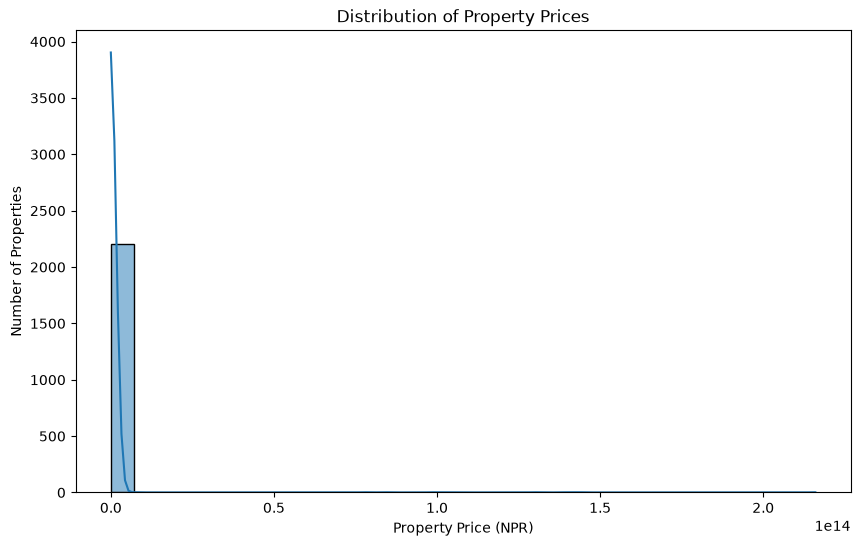

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Property Prices")
plt.xlabel("Property Price (NPR)")
plt.ylabel("Number of Properties")

plt.savefig(
    "../results/figures/price_distribution.png",
    bbox_inches="tight"
)

plt.show()

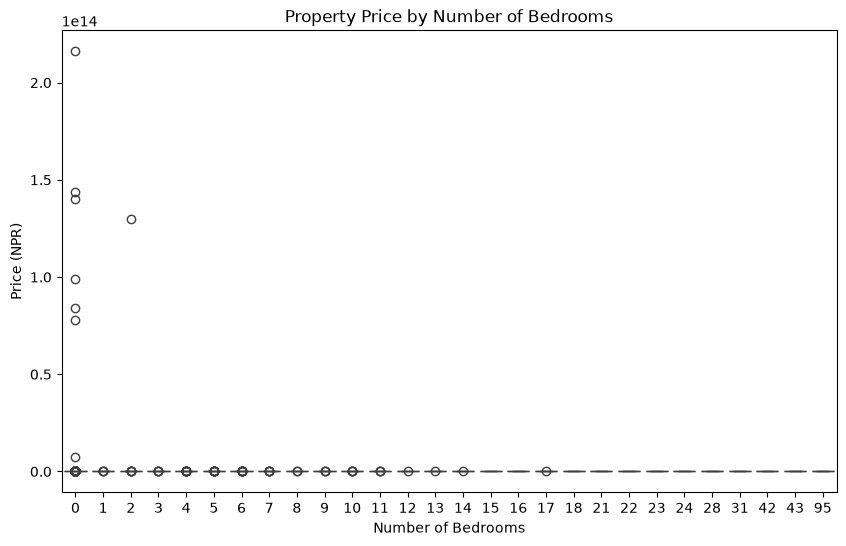

In [45]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="bedroom",
    y="price"
)

plt.title("Property Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (NPR)")

plt.savefig(
    "../results/figures/bedrooms_vs_price.png",
    bbox_inches="tight"
)

plt.show()

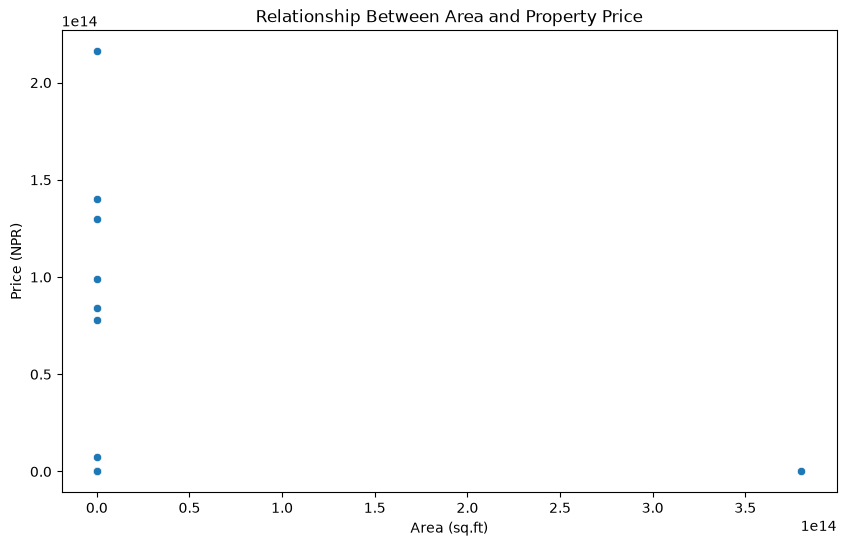

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="price"
)

plt.title("Relationship Between Area and Property Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (NPR)")

plt.savefig(
    "../results/figures/area_vs_price.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
top_cities = (
    data["city"]
    .value_counts()
    .head(10)
    .index
)

print(top_cities)

Index(['Kathmandu', 'Lalitpur', 'Bhaktapur', 'Pokhara', 'Chitwan', 'Makwanpur',
       'Nawalparasi', 'Dharan', 'Jhapa', 'Kavre'],
      dtype='object', name='city')


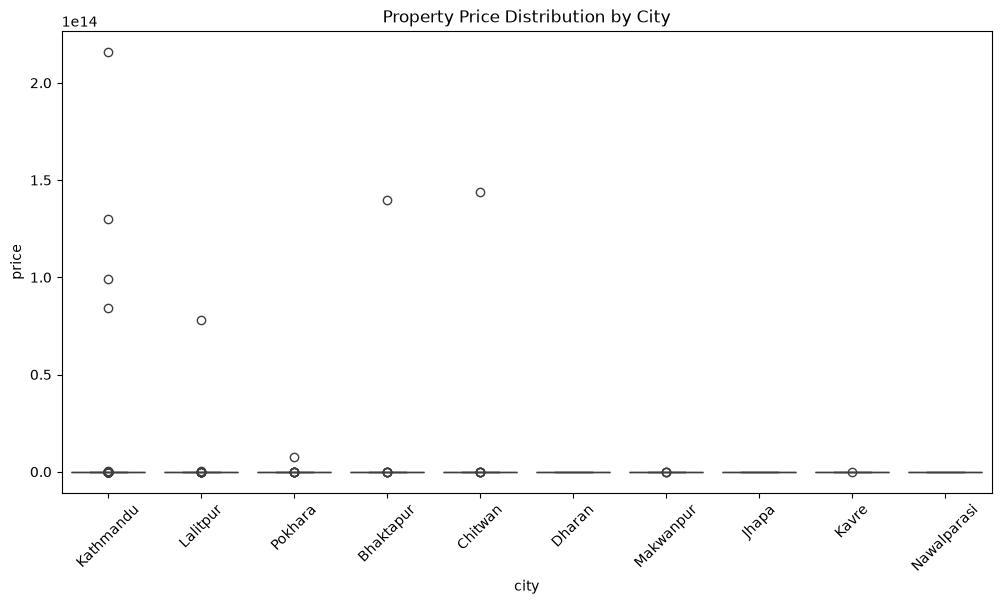

In [48]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data[
        data["city"].isin(top_cities)
    ],
    x="city",
    y="price"
)

plt.title("Property Price Distribution by City")

plt.xticks(rotation=45)

plt.savefig(
    "../results/figures/city_vs_price.png",
    bbox_inches="tight"
)

plt.show()

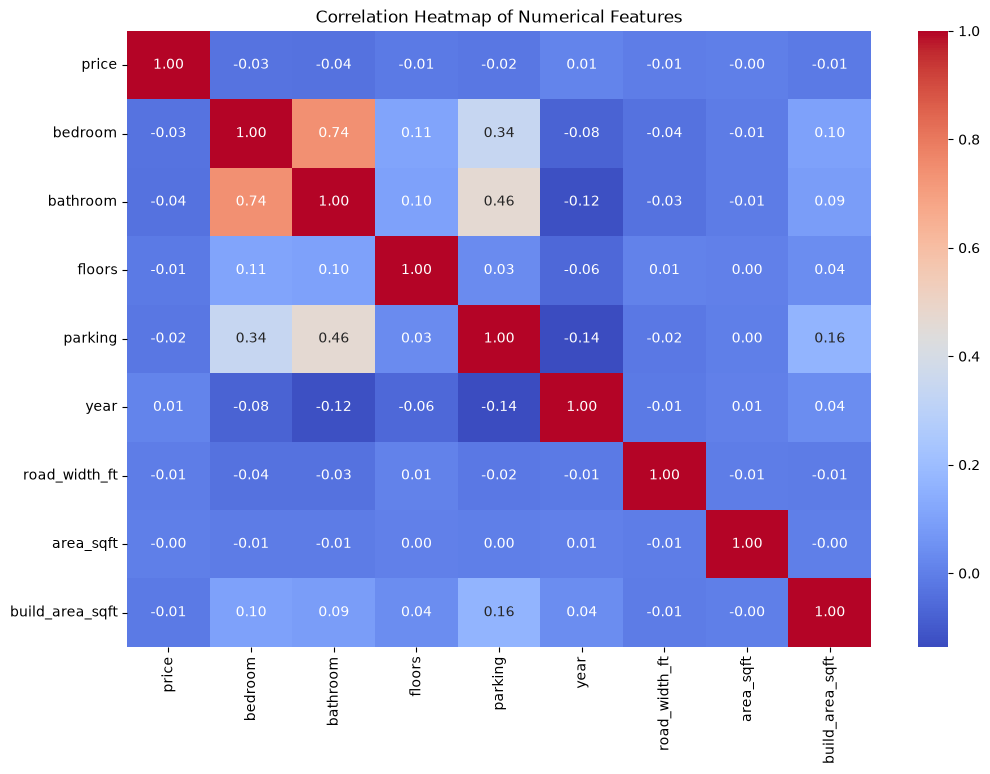

In [49]:
correlation_columns = [
    "price",
    "bedroom",
    "bathroom",
    "floors",
    "parking",
    "year",
    "road_width_ft",
    "area_sqft",
    "build_area_sqft"
]

correlation_data = data[
    correlation_columns
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)

plt.savefig(
    "../results/figures/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [50]:
print("========== EDA SUMMARY ==========")

print(
    "Average Price:",
    data["price"].mean()
)

print(
    "Median Price:",
    data["price"].median()
)

print(
    "Minimum Price:",
    data["price"].min()
)

print(
    "Maximum Price:",
    data["price"].max()
)

print(
    "Average Bedrooms:",
    data["bedroom"].mean()
)

print(
    "Average Bathrooms:",
    data["bathroom"].mean()
)

print(
    "Average Area (sq.ft):",
    data["area_sqft"].mean()
)

========== EDA SUMMARY ==========
Average Price: 406442810870.62146
Median Price: 8000000.0
Minimum Price: 15
Maximum Price: 216000002700000
Average Bedrooms: 2.731795567616463
Average Bathrooms: 1.8710990502035278
Average Area (sq.ft): 175891669524.66016
